In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold
from imblearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, recall_score,
    roc_auc_score, average_precision_score, cohen_kappa_score,
    precision_recall_curve, PrecisionRecallDisplay
)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
import xgboost as xgb

## Data Preparation

In [2]:
# =====================
# 1. Prepare Data
# =====================
df = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local
df.head(2)

X = df.drop(columns=['status'])
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

# print("Before SMOTE:", Counter(y_train))
# print("After SMOTE:", Counter(y_train_sm))

## Base model

In [3]:
# =====================
# 2. Base XGBoost Model (SMOTE outside pipeline)
# =====================
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

base_xgb = XGBClassifier(eval_metric='logloss', random_state=42)
base_xgb.fit(X_train_sm, y_train_sm)

# Predict
y_pred_base = base_xgb.predict(X_test)
y_proba_base = base_xgb.predict_proba(X_test)[:, 1]
y_train_pred_base = base_xgb.predict(X_train_sm)

# Print
print(confusion_matrix(y_test, y_pred_base))
print('------------------------------------------------------')
print(classification_report(y_test, y_pred_base, digits=3))
print('------------------------------------------------------')
print(f"Test Avg Precision: {average_precision_score(y_test, y_proba_base):.3f}")
print(f"Test AUC: {roc_auc_score(y_test, y_proba_base):.3f}")
print(f"Test Cohen's Kappa: {cohen_kappa_score(y_test, y_pred_base):.3f}")
print(f"Training recall: {recall_score(y_train_sm, y_train_pred_base):.3f}")

[[539 168]
 [185 419]]
------------------------------------------------------
              precision    recall  f1-score   support

           0      0.744     0.762     0.753       707
           1      0.714     0.694     0.704       604

    accuracy                          0.731      1311
   macro avg      0.729     0.728     0.728      1311
weighted avg      0.730     0.731     0.730      1311

------------------------------------------------------
Test Avg Precision: 0.812
Test AUC: 0.801
Test Cohen's Kappa: 0.457
Training recall: 0.854


In [4]:
# =====================
# 3. Tuned XGBoost using Pipeline + GridSearchCV
# =====================
pipe = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(eval_metric='logloss', random_state=42))
])

param_grid = {
    'xgb__n_estimators': [int(x) for x in np.linspace(start=50, stop = 150, num=5)],
    'xgb__max_depth': [4, 5, 6, 7],
    'xgb__learning_rate': [0.01, 0.1, 0.2],
    'xgb__subsample': [0.7, 0.8, 1],
    'xgb__colsample_bytree': [0.7, 0.8, 0.9]
}

grid_xgb = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='recall',  
    cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42),
    n_jobs=-1,
    verbose=2
)

grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_
y_pred_tuned = best_xgb.predict(X_test)
y_proba_tune = best_xgb.predict_proba(X_test)[:, 1]
y_train_pred_tune = best_xgb.predict(X_train)

# Evaluation
print("Best Parameters:", grid_xgb.best_params_)
print(confusion_matrix(y_test, y_pred_tuned))
print('------------------------------------------------------')
print(classification_report(y_test, y_pred_tuned, digits=3))
print('------------------------------------------------------')
print(f"Test Avg Precision: {average_precision_score(y_test, y_proba_tune):.3f}")
print(f"Test AUC: {roc_auc_score(y_test, y_proba_tune):.3f}")
print(f"Test Cohen's Kappa: {cohen_kappa_score(y_test, y_pred_tuned):.3f}")
print(f"Training recall: {recall_score(y_train, y_train_pred_tune):.3f}")

Fitting 15 folds for each of 540 candidates, totalling 8100 fits
Best Parameters: {'xgb__colsample_bytree': 0.7, 'xgb__learning_rate': 0.01, 'xgb__max_depth': 5, 'xgb__n_estimators': 75, 'xgb__subsample': 0.7}
[[524 183]
 [145 459]]
------------------------------------------------------
              precision    recall  f1-score   support

           0      0.783     0.741     0.762       707
           1      0.715     0.760     0.737       604

    accuracy                          0.750      1311
   macro avg      0.749     0.751     0.749      1311
weighted avg      0.752     0.750     0.750      1311

------------------------------------------------------
Test Avg Precision: 0.817
Test AUC: 0.823
Test Cohen's Kappa: 0.499
Training recall: 0.750


### 95% CI on Recall

Recall 95% CI: (0.724, 0.791)


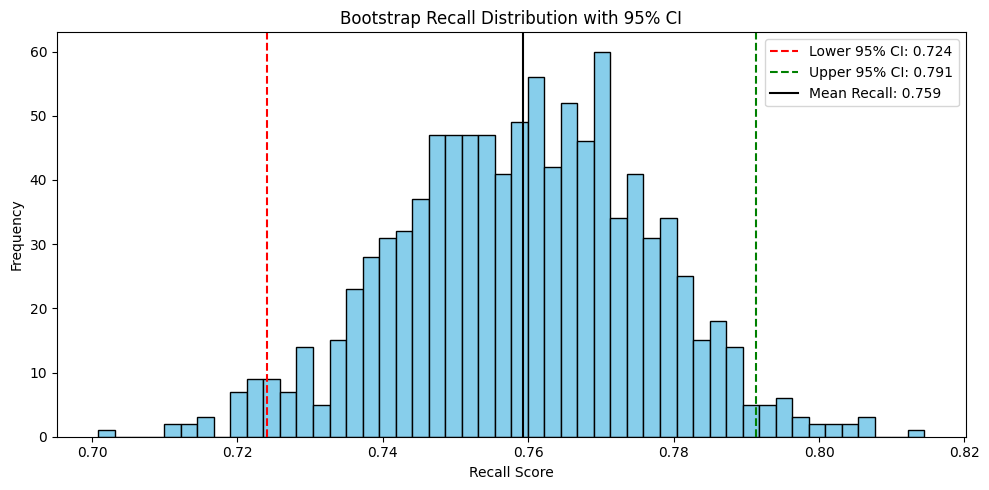

In [5]:
# Bootstrap
def bootstrap_ci_recall_distribution(y_true, y_pred_func, X, n_bootstraps=1000, alpha=0.95):
    rng = np.random.RandomState(42)
    bootstrapped_scores = []
    n = len(y_true)
    for _ in range(n_bootstraps):
        indices = rng.choice(np.arange(n), size=n, replace=True)
        if len(np.unique(y_true.iloc[indices])) < 2:
            continue
        score = recall_score(y_true.iloc[indices], y_pred_func(X.iloc[indices]))
        bootstrapped_scores.append(score)
    sorted_scores = np.sort(bootstrapped_scores)
    lower = np.percentile(sorted_scores, ((1-alpha)/2)*100)
    upper = np.percentile(sorted_scores, (alpha + (1-alpha)/2)*100)
    return bootstrapped_scores, lower, upper

# scores
recall_scores, lower_ci, upper_ci = bootstrap_ci_recall_distribution(
    y_test.reset_index(drop=True), 
    best_xgb.predict, 
    X_test.reset_index(drop=True)
)

print(f"Recall 95% CI: ({lower_ci:.3f}, {upper_ci:.3f})")

# plot
plt.figure(figsize=(10, 5))
plt.hist(recall_scores, bins=50, color='skyblue', edgecolor='black')
plt.axvline(lower_ci, color='red', linestyle='--', label=f"Lower 95% CI: {lower_ci:.3f}")
plt.axvline(upper_ci, color='green', linestyle='--', label=f"Upper 95% CI: {upper_ci:.3f}")
plt.axvline(np.mean(recall_scores), color='black', linestyle='-', label=f"Mean Recall: {np.mean(recall_scores):.3f}")
plt.title("Bootstrap Recall Distribution with 95% CI")
plt.xlabel("Recall Score")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

## Feature Importance

                            Feature  Base Model  Tuned Model
0                         child_age    0.254324     0.233799
1                      child_weight    0.098422     0.225922
6                  mother_education    0.048578     0.096768
8                      wealth_index    0.047530     0.068621
10        province_Karnali Province    0.053083     0.058834
12              province_Province 2    0.063549     0.052026
9         province_Gandaki Province    0.060912     0.047322
11              province_Province 1    0.047883     0.037824
13              province_Province 5    0.049060     0.036067
14  province_Sudoorpaschim Province    0.048112     0.035052
4                              area    0.043935     0.028482
5                         child_sex    0.066586     0.025575
7                  health_insurance    0.038102     0.021867
2            diarrhoea_last_2_weeks    0.040295     0.017649
3                fever_last_2_weeks    0.039629     0.014192


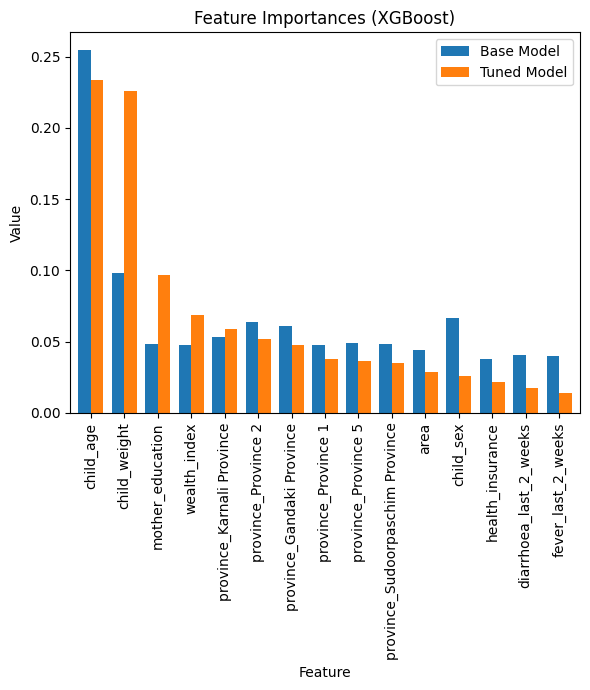

In [ ]:
# Get feature names
feature_names = X.columns

# Extract the XGBoost model from the pipeline
xgb_tuned_model = best_xgb.named_steps['xgb']  # from pipeline
xgb_base_model = base_xgb  # directly used without pipeline

# Get feature importances
importances_base = xgb_base_model.feature_importances_
importances_tuned = xgb_tuned_model.feature_importances_

# Combine into DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Base Model': importances_base,
    'Tuned Model': importances_tuned
}).sort_values(by='Tuned Model', ascending=False)

print(importance_df)

# Plot
top_features = importance_df.set_index('Feature')

top_features.plot(kind='bar', figsize=(6, 7), width = 0.75)
plt.title('Feature Importances (XGBoost)')
plt.xlabel('Feature')
plt.ylabel('Value')
# plt.gca().invert_yaxis()
# plt.grid(True, axis='x')
plt.tight_layout()
plt.show()


## Average Precision Plot

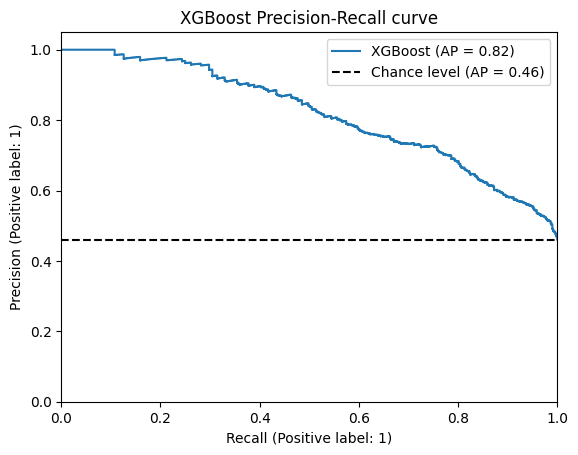

In [ ]:
display = PrecisionRecallDisplay.from_estimator(
    best_xgb,            # Trained model
    X_test,              # Test features
    y_test,              # True labels
    name="XGBoost",          # Name for legend
    plot_chance_level=True  # Automatically plots chance-level baseline
)

display.ax_.set_title("XGBoost Precision-Recall curve")
display.ax_.legend(loc='upper right')
display.ax_.set_xlim([0.0, 1.0])
display.ax_.set_ylim([0.0, 1.05])
plt.show()

## Additional

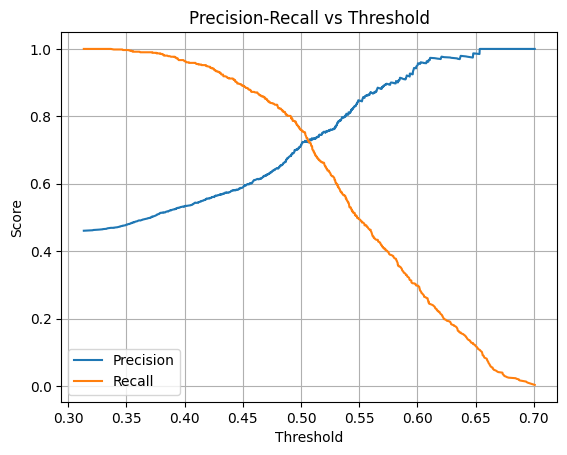

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_tune)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.grid()
plt.legend()
plt.show()

In [ ]:
# Apply custom threshold
y_proba_custom = (y_proba_tune >= 0.40).astype(int)
print(f'Classification Report: \n{classification_report(y_test, y_proba_custom)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0       0.90      0.28      0.43       707
           1       0.53      0.96      0.69       604

    accuracy                           0.59      1311
   macro avg       0.72      0.62      0.56      1311
weighted avg       0.73      0.59      0.55      1311


